## Using APIs in Projects


When getting data from APIs, I strongly suggest following a three-step workflow:

1. Write some code that gets data from an API and saves all of the data (if possible) to a file
2. Write a second program (usually a second file) that loads the data from the API, extracts the data that will be useful for analysis, and saves it in a flat file (typically a CSV).
3. Program number 3 loads the CSV file and does the analysis

This approach has a few important benefits.

The first and most important is that often it is difficult to get the same raw data again. For example, some APIs only lets you get the last week. If you are doing analysis a month down the road and decide that you really wish you had saved different metadata, it is too late. By saving as much of the raw data as possible you can change your measures or analysis strategy in the future (or even do additional studies)

The second benefit is that this gives you a nice pipeline, with intermediate files. Instead of including the entire raw data file in the code that does analysis, you only have to load the CSV, which is often much smaller and easier to work with.

This brief lesson will show an example of this workflow, using `atproto` to get data from the Bluesky API.

Note that I'm going to put everything in one file for convenience, but my typical workflow is to put these in separate files and then run each file separately.

## Research Question

What are the main groups of people who post about Purdue?

To answer this question, we will identify the last 1000 people who posted about Purdue. We will then grab all of the recent posts from those people, cluster them based on following relationships, and then use TF-IDF to identify the main topics of discussion for each cluster.

## Program 1 - Data Retrieval

So, we need three main pieces of data:

1. The last 1000 people who posted about Purdue
2. The recent posts from those people
3. The follower network of those people

We'll save each of these to a separate file, so that we can easily change our analysis later if we want to. For example, maybe we want to look at the last 10,000 people who posted about Purdue instead of just 1,000. If we have the data saved, we can easily change our code to analyze the new data without having to worry about how to get it again.

In [ ]:
import atproto
import bluesky_auth

at_client = atproto.Client()
at_client.login(bluesky_auth.USERNAME, bluesky_auth.PASSWORD);

We're going to grab all of the recent posts that mention Purdue, until we have 1000 unique posters.

In [ ]:
import csv


def get_posts(query, n=100, cursor=None):
    params = {'q': query, 'limit': n}
    if cursor is not None:
        params['cursor'] = cursor
    response = at_client.app.bsky.feed.search_posts(params)
    return response


posters = set()
with open('recent_purdue_posts.csv', 'w', newline='', encoding='utf-8') as csvfile:
    fieldnames = ['author', 'text', 'like_count', 'repost_count', 'uri', 'timestamp']
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
    writer.writeheader()
    # Now get 1000 unique posters, and save their posts to the CSV file
    i = 0
    cursor = None
    while True:
        response = get_posts('Purdue', n=100, cursor=cursor)
        cursor = response.cursor
        for post in response.posts:
            if i % 100 == 0:
                print(f'Got {len(posters)} unique posters so far...')
            i += 1
            if post.author.handle not in posters:
                posters.add(post.author.handle)
            # Save as much data as you think you might possibly want, so that you can easily change your analysis later without having to worry about how to get the data again.
            writer.writerow({
                'author': post.author.handle,
                'text': post.record.text,
                'like_count': post.like_count,
                'repost_count': post.repost_count,
                'uri': post.uri,
                'timestamp': post.record.created_at
            })
            if len(posters) >= 1000:
                break
        if len(posters) >= 1000:
            break



In [44]:
# Let's take a look at the data we just saved, to make sure it looks right.
import pandas as pd
df = pd.read_csv('recent_purdue_posts.csv')
df

,author,text,like_count,repost_count,uri,timestamp
0,justtmill.bsky.social,Purdue starting the 2026-27 season vs. Gonzaga...,3,0,at://did:plc:bxpvnfkafn6rhc34ho5zpr6b/app.bsky...,2026-02-25T20:12:51.683Z
1,jsthrill.modphi.com,i saw goodie purdue using counterexamples with...,1,0,at://did:plc:ov6ksblbmitfo45xyfia4nk7/app.bsky...,2026-02-25T19:32:01.826Z
2,miamurphy.com,"oooohh, WHLMA is part of the Purdue system, I ...",7,0,at://did:plc:uzfi6wm4fzhfjf2f65muroot/app.bsky...,2026-02-25T19:28:13.569Z
3,kennethblack.bsky.social,This post can only be defeated by an observati...,5,1,at://did:plc:mmmwbmu67eonala4pqk424pt/app.bsky...,2026-02-25T19:27:53.097Z
4,symmering.bsky.social,Las Vegas will host the Hall of Fame Series Op...,0,0,at://did:plc:hbzuhl2aulzwxwm2pc5ozz5t/app.bsky...,2026-02-25T19:24:15.845Z
...,...,...,...,...,...,...
2202,trevorandershock.bsky.social,Instant analysis: Indiana takes down Purdue 72...,1,0,at://did:plc:j7jtyox34dxxd7mjxv37tyqk/app.bsky...,2026-01-28T08:00:14.561Z
2203,rookiesims.bsky.social,"lol, I guess Purdue just doesn’t have that cha...",2,0,at://did:plc:vao7f2ujsdks2bp3xpcdbk7h/app.bsky...,2026-01-28T07:27:50.509Z
2204,patmcafeeshow.bsky.social,HUGE HOO HOO HOO Hoosiers win over Purdue in h...,19,1,at://did:plc:3cbuk7cmdud75vbagnsm74sh/app.bsky...,2026-01-28T07:18:36.722Z
2205,cryptoinsight05.bsky.social,Indiana sends No. 12 Purdue to third consecuti...,0,0,at://did:plc:6534g5yeqfishwqkqhcjsj6e/app.bsky...,2026-01-28T06:32:07Z


### Program 2 - Recent Posts

Now, let's get the recent posts from these people. We'll save this in a separate file, to make it easy to adjust our pipeline. I'll also show you how to checkpoint your data retrieval, so that if you have to stop and start again, you don't lose all of your progress.

In [47]:
def get_recent_posts(author, n=100, cursor=None):
    posts = []
    while len(posts) < n:
        response = at_client.get_author_feed(actor=author, limit=100, cursor=cursor)
        posts.extend(response.feed)
        if not response.feed:
            break
        cursor = response.cursor
    return posts


POSTS_PER_POSTER = 100


df = pd.read_csv('recent_purdue_posts.csv')
posters = set(df['author'])
print(f'There are {len(posters)} unique posters.')

# Check if we have already started getting the recent posts for these posters, and if so, load the list of posters we've already gotten.
try:
    with open('posters_other_posts.csv', 'r', newline='', encoding='utf-8') as csvfile:
        reader = csv.DictReader(csvfile)
        retrieved_posters = set([row['poster'] for row in reader])
except FileNotFoundError:
    retrieved_posters = set()

with open('posters_other_posts.csv', 'a', newline='', encoding='utf-8') as csvfile:
    fieldnames = ['poster', 'author', 'text', 'like_count', 'repost_count', 'uri']
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
    i = len(retrieved_posters)
    if len(retrieved_posters) == 0:
        writer.writeheader()
    for poster in posters:
        if poster in retrieved_posters:
            continue
        posts = get_recent_posts(poster, n=POSTS_PER_POSTER)
        for feed_item in posts:
            post = feed_item.post
            writer.writerow({
                'poster': poster,
                'author': post.author.handle,
                'text': post.record.text,
                'like_count': post.like_count,
                'repost_count': post.repost_count,
                'uri': post.uri
            })
        i += 1
        if i % 50 == 0:
            print(f'Finished processing {i} posters.')

There are 1000 unique posters.
Finished processing 150 posters.
Finished processing 200 posters.
Finished processing 250 posters.
Finished processing 300 posters.
Finished processing 350 posters.
Finished processing 400 posters.
Finished processing 450 posters.
Finished processing 500 posters.
Finished processing 550 posters.
Finished processing 600 posters.
Finished processing 650 posters.
Finished processing 700 posters.
Finished processing 750 posters.
Finished processing 800 posters.
Finished processing 850 posters.
Finished processing 900 posters.
Finished processing 950 posters.
Finished processing 1000 posters.


In [48]:
recent_posts_df = pd.read_csv('posters_other_posts.csv')
recent_posts_df

,poster,author,text,like_count,repost_count,uri
0,1011now.com,1011now.com,HVAC upgrades prompt temporary canine housing ...,1,1,at://did:plc:yvqeynrczqvphzcrjh24s5zf/app.bsky...
1,1011now.com,1011now.com,StarCare responds to Highway 2 crash in Otoe C...,0,0,at://did:plc:yvqeynrczqvphzcrjh24s5zf/app.bsky...
2,1011now.com,1011now.com,Lincoln Public Schools names next director of ...,0,0,at://did:plc:yvqeynrczqvphzcrjh24s5zf/app.bsky...
3,1011now.com,1011now.com,Car fire briefly slows traffic on I-80 near Wa...,0,0,at://did:plc:yvqeynrczqvphzcrjh24s5zf/app.bsky...
4,1011now.com,1011now.com,Car fire slows traffic on I-80 near Waverly,0,0,at://did:plc:yvqeynrczqvphzcrjh24s5zf/app.bsky...
...,...,...,...,...,...,...
117734,fleaingdogfella.bsky.social,fleaingdogfella.bsky.social,"""But it worked so well in Danzig in 1939!!""",3,1,at://did:plc:utkawv7im6jf73n4z4sv5hhm/app.bsky...
117735,fleaingdogfella.bsky.social,thegoldenratio4.bsky.social,Daily snaps 2/20/26\nyoutube.com/shorts/B9r1q...,123,6,at://did:plc:peyrokrtgg3ov3bddzusnerv/app.bsky...
117736,fleaingdogfella.bsky.social,schooley.bsky.social,I still don't understand how this isn't the he...,3932,1104,at://did:plc:kdphmaoqeaouax2kis27556e/app.bsky...
117737,fleaingdogfella.bsky.social,fleaingdogfella.bsky.social,Purdue was run by former Indiana governor Mitc...,1,0,at://did:plc:utkawv7im6jf73n4z4sv5hhm/app.bsky...


### Program 3 - Follower Network

Finally, we'll get the follower network of these people. This will allow us to cluster them based on who follows whom, which can give us insights into the different groups of people who are posting about Purdue.

This will take a while, so we'll save this data to a file as well.

Note that the code below only saves the followers who have also posted about Purdue. It might be a better idea to save all of the followers, in case you wanted to do a different analysis later.

In [50]:
import pandas as pd
import csv
import time

def get_all_follows(client, handle, max_follows=5000):
    # Get all of the accounts the user follows, handling pagination
    follows = []
    cursor = None
    while True:
        response = client.get_follows(handle, limit=100, cursor=cursor)
        follows.extend(response.follows)
        if response.cursor is None:
            break
        cursor = response.cursor
        if len(follows) >= max_follows:
            break
    return follows

df = pd.read_csv('recent_purdue_posts.csv')
posters = set(df['author'])

try:
    with open('follow_network.csv', 'r', newline='', encoding='utf-8') as csvfile:
        reader = csv.DictReader(csvfile)
        retrieved_posters = set([row['from'] for row in reader])
except FileNotFoundError:
    retrieved_posters = set()

# Get all of the accounts the top posters follow, and see which of the top posters follow each other.
with open('follow_network.csv', 'a', newline='', encoding='utf-8') as csvfile:
    fieldnames = ['from', 'to']
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
    if len(retrieved_posters) == 0:
        writer.writeheader()
    i = len(retrieved_posters)
    for poster in posters:
        if poster in retrieved_posters:
            continue
        follows = get_all_follows(at_client, poster)
        for f in follows:
            writer.writerow({'from': poster, 'to': f.handle})
        i += 1
        if i % 50 == 0:
            print(f"Processed {i} posters out of {len(posters)}.")
            time.sleep(20)  # Sleep for a bit to avoid hitting rate limits

Processed 100 posters out of 1000.
Processed 150 posters out of 1000.
Processed 200 posters out of 1000.
Processed 250 posters out of 1000.
Processed 300 posters out of 1000.
Processed 350 posters out of 1000.
Processed 400 posters out of 1000.
Processed 450 posters out of 1000.
Processed 500 posters out of 1000.
Processed 550 posters out of 1000.
Processed 600 posters out of 1000.
Processed 650 posters out of 1000.
Processed 700 posters out of 1000.
Processed 750 posters out of 1000.
Processed 800 posters out of 1000.
Processed 850 posters out of 1000.
Processed 900 posters out of 1000.
Processed 950 posters out of 1000.
Processed 1000 posters out of 1000.


In [51]:
df = pd.read_csv('follow_network.csv')
df

,from,to
0,1011now.com,knopnews2.com
1,1011now.com,ksnblocal4.com
2,1011now.com,bsky.app
3,paulguinnessy.bsky.social,eejbro.bsky.social
4,paulguinnessy.bsky.social,macroliter.bsky.social
...,...,...
596061,fleaingdogfella.bsky.social,sean-dunn.bsky.social
596062,fleaingdogfella.bsky.social,fiftyshadesofwhey.bsky.social
596063,fleaingdogfella.bsky.social,lawsuitsdevin.bsky.social
596064,fleaingdogfella.bsky.social,nunesalt.bsky.social


Now, we'll filter to just the followers who also posted about Purdue, and save that to a file as well.

In [52]:
df = pd.read_csv('follow_network.csv')

df_filtered = df[df['to'].isin(posters)]
df_filtered.to_csv('follow_network_filtered.csv', index=False)

## Analysis

Now, we'll load the follower network and do some clustering. We'll use a simple community detection algorithm to identify clusters of people who follow each other, and then we'll use TF-IDF to identify the main topics of discussion for each cluster.

In [53]:
import networkx as nx
import matplotlib.pyplot as plt

df = pd.read_csv('follow_network_filtered.csv')

G = nx.from_pandas_edgelist(df, source='from', target='to')
communities = nx.community.greedy_modularity_communities(G)
for i, community in enumerate(communities):
    print(f'Community {i}: {len(community)} members')


Community 0: 277 members
Community 1: 236 members
Community 2: 188 members
Community 3: 54 members
Community 4: 13 members
Community 5: 6 members
Community 6: 3 members
Community 7: 3 members
Community 8: 3 members
Community 9: 2 members
Community 10: 2 members
Community 11: 2 members
Community 12: 2 members
Community 13: 2 members
Community 14: 2 members
Community 15: 2 members
Community 16: 2 members
Community 17: 2 members


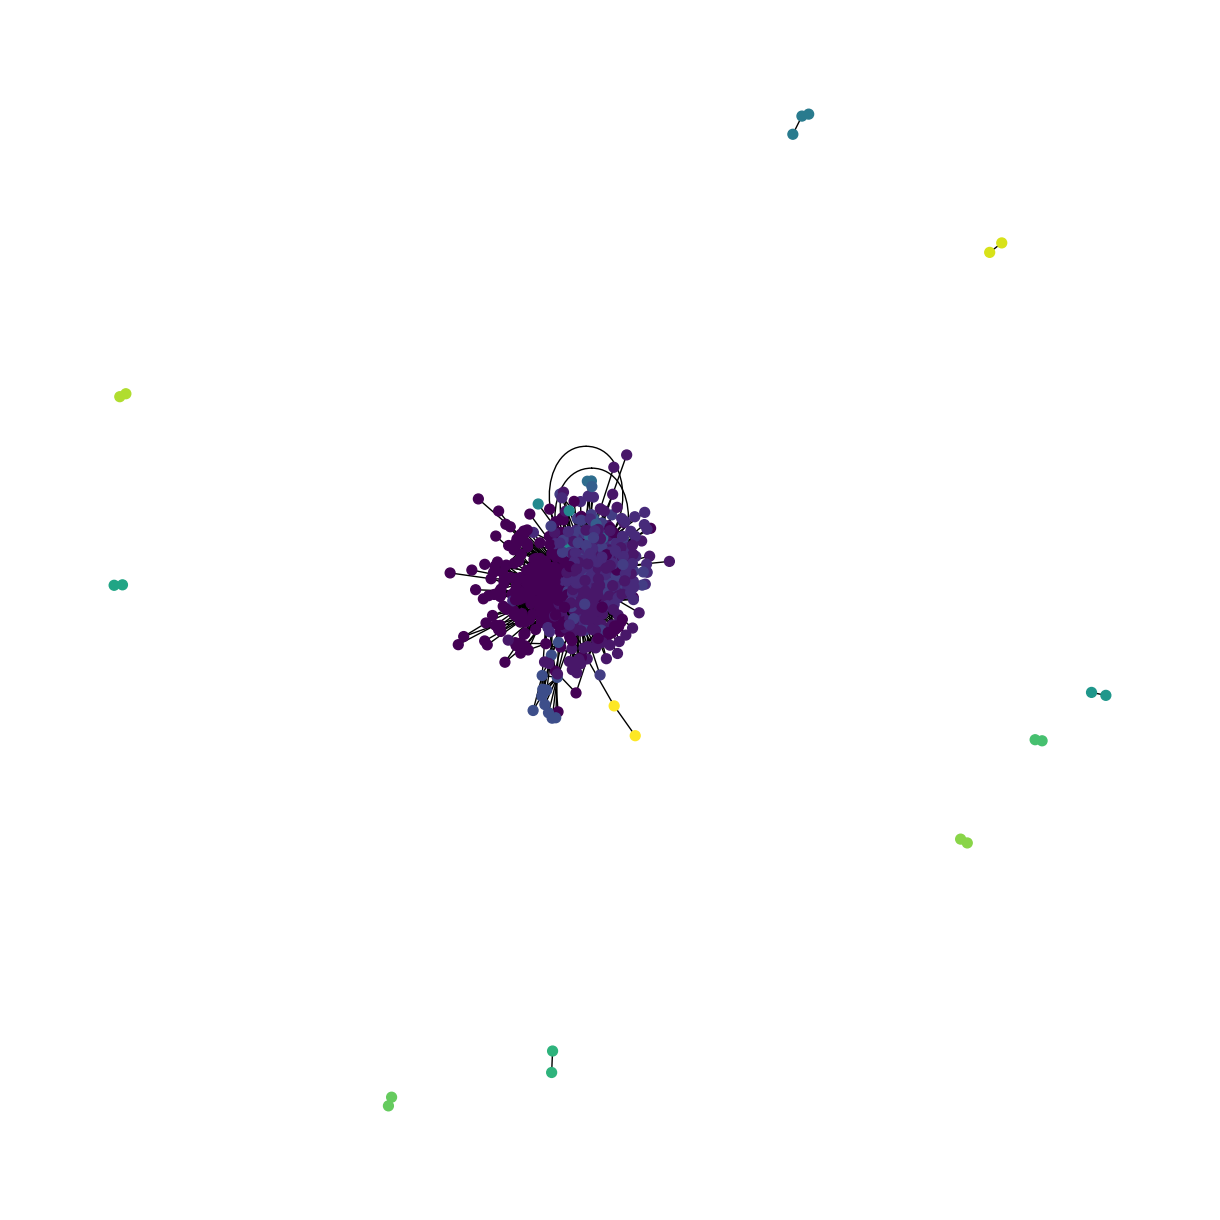

In [54]:
# Make a visualization of the follower network, coloring the nodes by community.
color_map = {}
for i, community in enumerate(communities):
    for node in community:
        color_map[node] = i
colors = [color_map[node] for node in G.nodes()]
plt.figure(figsize=(12, 12))
# Layout with spring layout
nx.spring_layout(G, seed=42)
nx.draw(G, node_color=colors, with_labels=False, node_size=50, font_size=8)
plt.show()

In [57]:
# TF IDF Analysis
import re
from sklearn.feature_extraction.text import TfidfVectorizer

other_posts_df = pd.read_csv('posters_other_posts.csv')

# Ensure text is string, then remove URLs
other_posts_df['text'] = (
    other_posts_df['text']
    .fillna('')
    .astype(str)
    .str.replace(r'https?://\S+|www\.\S+', '', regex=True)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

tfidf = TfidfVectorizer(stop_words='english')

# First, we'll get all of the text from the posters in each cluster, and then we'll use TF-IDF to identify the main topics of discussion for each cluster.

community_texts = []
for community in communities:
    community_text = ' '.join(other_posts_df[other_posts_df['poster'].isin(community)]['text'])
    community_texts.append(community_text)
tfidf_matrix = tfidf.fit_transform(community_texts)
feature_names = tfidf.get_feature_names_out()
for i, community in enumerate(communities):
    if len(community) < 3:  # Skip small communities
        continue
    print(f'Community {i}:')
    top_n = 20
    # Get the indices of the top n features for this community
    top_indices = tfidf_matrix[i].toarray()[0].argsort()[-top_n:][::-1] 
    # Get the words corresponding to the top indices
    top_features = [feature_names[index] for index in top_indices]
    print('\t' + '\n\t'.join(top_features))
    

Community 0:
	trump
	people
	x1
	just
	like
	bsky
	com
	epstein
	social
	state
	don
	new
	ice
	think
	time
	right
	know
	ai
	good
	2026
Community 1:
	game
	just
	com
	indiana
	like
	iubb
	team
	state
	time
	purdue
	people
	win
	basketball
	good
	season
	don
	bsky
	big
	think
	social
Community 2:
	michigan
	just
	like
	game
	iowa
	don
	com
	think
	team
	people
	time
	good
	know
	really
	football
	hockey
	state
	college
	basketball
	win
Community 3:
	like
	nebraska
	just
	people
	huskers
	don
	think
	nebraskacornhuskers
	nebraskahuskers
	basketball
	gbr
	edgesports
	ai
	com
	know
	game
	really
	new
	time
	cornhuskers
Community 4:
	memory
	thememor
	palace
	social
	bsky
	com
	substack
	philosophy
	today
	philsky
	pub
	caic
	university
	open
	research
	post
	philscisky
	gencon
	mitpress
	like
Community 5:
	brewerfanatic
	alert
	brewers
	ncaab
	forums
	com
	watch
	topic
	espn
	bsky
	soccer
	social
	archived
	2nd
	half
	just
	chourio
	state
	like
	media
Community 6:
	think
	like
	just
	guys
